<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 12 </b></center>
<pre>    

# Step 1: Import Libraries

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Step 2: Generate dummy data using make_blobs

In [7]:
x, y = make_blobs(n_samples=20, centers=3, random_state=42)


# Step 3: Plot Generated data

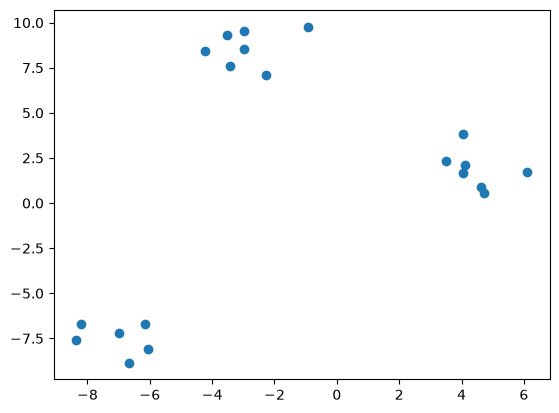

In [8]:
plt.scatter(x[:,0],x[:,1])

# Step 4: Apply Hierarchical Clustering

In [18]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=2)
y_hc = hc.fit_predict(x)

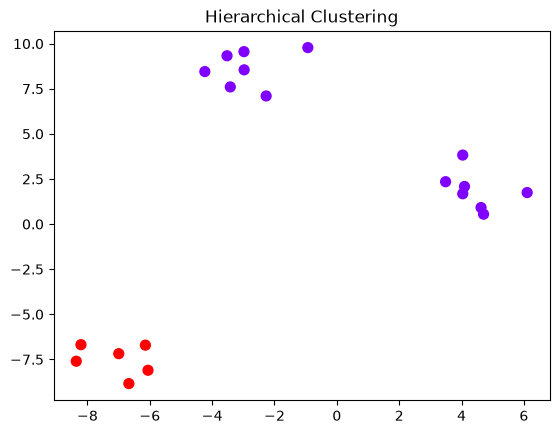

In [19]:
import matplotlib.pyplot as plt

plt.scatter(x[:, 0], x[:, 1], c=y_hc, cmap='rainbow', s=50)
plt.title('Hierarchical Clustering')
plt.show()

# Step 5: Display Dendrogram

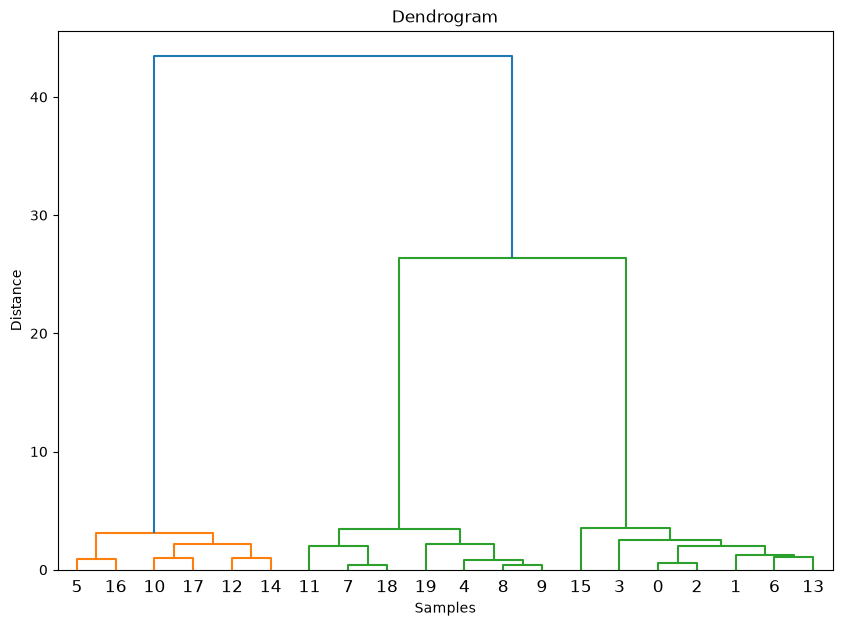

In [ ]:
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(x, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()

# Step 6: Generate dummy data using make_moons

In [ ]:
from sklearn.datasets import make_moons

x_moons, y_moons = make_moons(n_samples=300, noise=0.09, random_state=42)

# Step 7: Plot Generated data

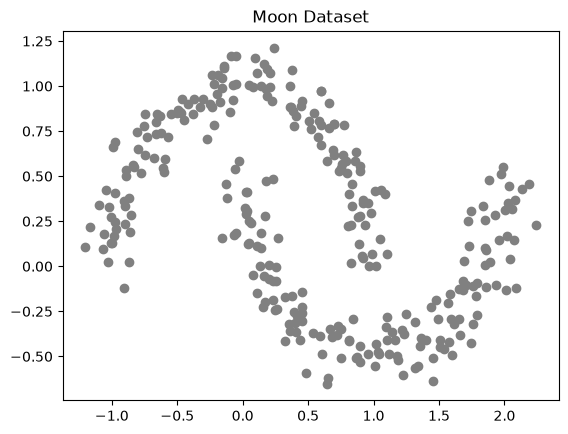

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_moons[:, 0], x_moons[:, 1], c='gray')
plt.title('Moon Dataset')
plt.show()

# Step 8: apply DBSCAN Clustering

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(x_moons)

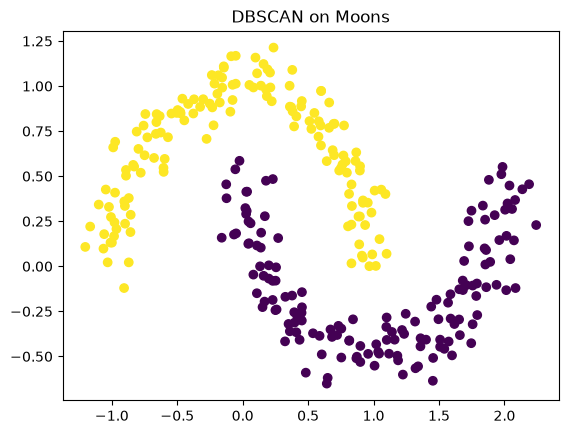

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_moons[:, 0], x_moons[:, 1], c=y_dbscan, cmap='viridis')
plt.title('DBSCAN on Moons')
plt.show()

# Step 9: apply K Mean Clustering on same data

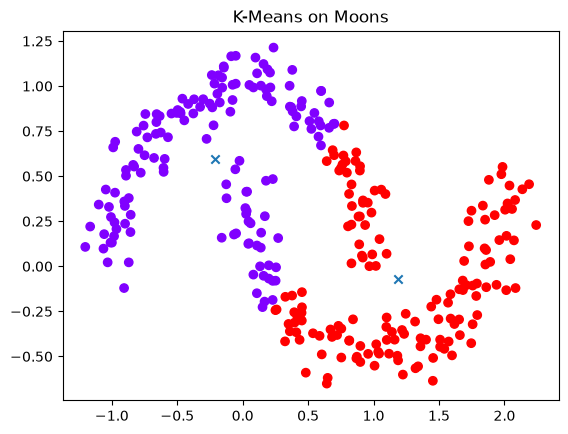

In [17]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
y_kmeans = kmeans.fit_predict(x_moons)
center = kmeans.cluster_centers_

plt.scatter(x_moons[:, 0], x_moons[:, 1], c=y_kmeans, cmap='rainbow')
plt.scatter(center[:, 0], center[:, 1],marker="x")
plt.title('K-Means on Moons')
plt.show()

## Mall Customers Segmentation using DBSCAN

### Perform Following steps on Dataset for  customer segmentation
-> Load & Explore the Dataset <br>
-> Data Preprocessing <br>
-> Apply DBSCAN <br>
-> Visualizing Customer Segments <br>
-> Outliers (high-spending VIP customers or unusual shoppers <br>

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('Mall_Customers.csv')
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
X_customer = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_customer)

In [ ]:
# Apply DBSCAN
db_customer = DBSCAN(eps=0.35, min_samples=5)
labels = db_customer.fit_predict(X_scaled)

# Add cluster results to original dataframe
df['Cluster'] = labels

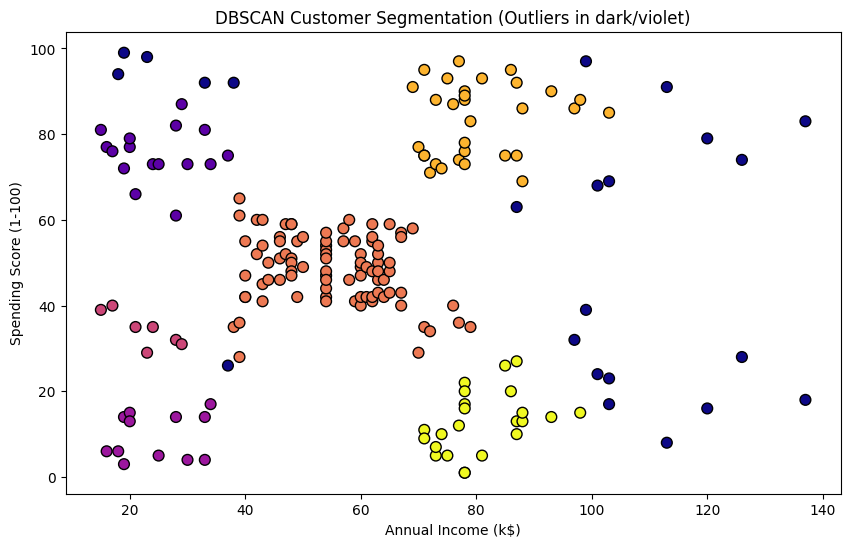

In [ ]:
import matplotlib.pyplot as plt

# Simpler customer visualization using colors to distinguish clusters and outliers
plt.figure(figsize=(10, 6))
plt.scatter(X_customer[:, 0], X_customer[:, 1], c=labels, cmap='plasma', s=60, edgecolors='k')
plt.title('DBSCAN Customer Segmentation (Outliers in dark/violet)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()


# import matplotlib.pyplot as plt
# import numpy as np

# # Distinct plotting with proper legend mapping
# plt.figure(figsize=(10, 6))
# unique_labels = np.unique(labels)

# # Create a distinct color map (using tab10 or similar clear categorical colors)
# colors = plt.cm.get_cmap('tab10', len(unique_labels))

# for i, cluster_id in enumerate(sorted(unique_labels)):
#     member_mask = (labels == cluster_id)
#     cluster_points = X_customer[member_mask]

#     if cluster_id == -1:
#         # Highlight outliers as distinct black/dark dots with label
#         plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c='black', s=70, label='Outliers', edgecolors='k', zorder=2)
#     else:
#         # Plot normal clusters
#         plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors(i), s=60, label=f'Cluster {cluster_id}', edgecolors='k', alpha=0.9)

# plt.title('DBSCAN Customer Segmentation (with Outliers)')
# plt.xlabel('Annual Income (k$)')
# plt.ylabel('Spending Score (1-100)')
# plt.legend(loc='best')
# plt.grid(True, linestyle='--', alpha=0.5)
# plt.show()

In [ ]:
# Identify and Display Outlier Customer Data
outliers = df[df['Cluster'] == -1]
print(f"Total Outliers Detected: {len(outliers)}")
display(outliers.head(10))

Total Outliers Detected: 23


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
7,8,Female,23,18,94,-1
11,12,Female,35,19,99,-1
19,20,Female,35,23,98,-1
33,34,Male,18,33,92,-1
38,39,Female,36,37,26,-1
41,42,Male,24,38,92,-1
169,170,Male,32,87,63,-1
180,181,Female,37,97,32,-1
184,185,Female,41,99,39,-1
185,186,Male,30,99,97,-1
